# W04A - Harmonic Oscillator 1D

### Task 1 - repeat Metropolis monte carlo

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class Spring ():
    def __init__(self, k=1, x0=0):
        self.k = k
        self.x0 = x0

    # to be used in the MC
    def potential_energy(self, x):
        return 0.5 * self.k * (x - self.x0)**2

    # to be used in the MD
    def force(self, x):
        return -self.k * (x - self.x0)

In [9]:
class MetropolisMonteCarlo():
    def __init__(self, calc, kT=0.15, xmin=-3, xmax=3, Nsamples=100000):
        self.calc = calc
        self.kT = kT
        self.xmin = xmin
        self.xmax = xmax
        self.x = self.calc.x0
        self.Nsamples = Nsamples

        self.xspace = np.linspace(self.xmin, self.xmax, 100)
        self.energy = self.calc.potential_energy(self.calc.x0)
        self.energies = self.calc.potential_energy(self.xspace)
        #self.force = self.calc.force(self.xspace)

        self.counts, self.bin_edges = self.run_Metropolis_Monte_Carlo()
        self.bin_centers = 0.5 * (self.bin_edges[:-1] + self.bin_edges[1:])

        self.p_exact = np.exp(-self.energies / self.kT)
        self.p_exact /= np.trapezoid(self.p_exact, self.xspace)   # divide by true area

    def proposed_x(self):
        return np.random.rand() * abs(self.xmax - self.xmin) + self.xmin
    
    def step(self):
        proposed_x = self.proposed_x()
        proposed_energy = self.calc.potential_energy(proposed_x)
        delta_V = proposed_energy - self.energy
        acceptance_probability = min(1, np.exp(-delta_V / self.kT))  # using P(x')/P(x) = exp(-E'/kT)/exp(E/kT) = exp(-delta_E/kT)
        # a clever way to choose randomly given a probability
        # if acceptance_probability=0.4, it is chosen 40% of times.
        if np.random.rand() < acceptance_probability:
            self.x = proposed_x
            self.energy = proposed_energy
    
    def run_Metropolis_Monte_Carlo(self):
        self.visited_states = [self.x]  # get initial position too
        for _ in range(self.Nsamples):
            self.step()
            self.visited_states.append(self.x)
        counts, bin_edges = np.histogram(self.visited_states, bins=abs(self.xmax-self.xmin)*8+1, range=(self.xmin, self.xmax))
        probabilites = counts/np.sum(counts)  # get mmc probabilites
        return probabilites, bin_edges  

    def thermal_avg_exact(self):
        return 1/2*self.kT

    def thermal_avg(self):
        return np.mean([self.calc.potential_energy(x) for x in self.visited_states])

    def plot(self, ax):
        bin_width = self.bin_edges[1] - self.bin_edges[0]
        P = self.counts/bin_width
        ax.bar(self.bin_centers, P, width=bin_width, facecolor ='C0', alpha =0.25)
        ax.bar(self.bin_centers, P, width=bin_width, facecolor ='None', edgecolor ='k')
        ax.set_title(r'$\langle V\rangle_{exact}=$'+f'{self.thermal_avg_exact():.3f}'+', 'r'$\langle V\rangle=$'+f'{self.thermal_avg():.3f}')
        ax.plot(self.xspace, self.p_exact, 'k')
        ax.plot(self.xspace, self.calc.potential_energy(self.xspace), 'k')
        ax.text(0, 2.5, r'$kT=$'+f'{self.kT}', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.5,edgecolor='none'))
        ax.set_ylim(0,3)

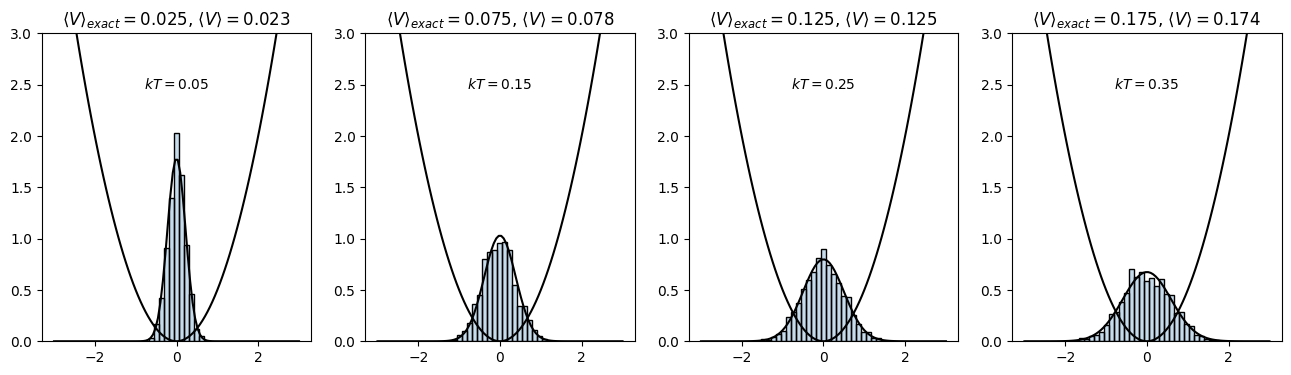

In [10]:
spring = Spring()

fig, axes = plt.subplots(1,4,figsize=(16,4))

for kT, ax in zip([0.05, 0.15, 0.25, 0.35],axes):
    met_mc = MetropolisMonteCarlo(spring, kT=kT, Nsamples=10_000)
    met_mc.plot(ax)

### Task 2 - Implement velocity Verlet algorithm with constant energy MD

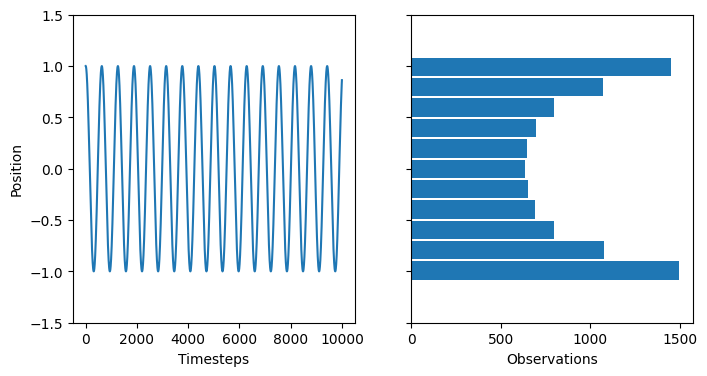

In [5]:
def velocity_verlet(mdsys, N=100):
    rs = []
    for _ in range(N):
        dt = 0.01
        r = mdsys.get_position()
        v = mdsys.get_velocity()
        a_t = mdsys.force() # assume m=1

        # 1. update position
        r += v*dt + 1/2*a_t*dt**2
        mdsys.set_position(r)

        # 2. evaluate force and acceleration 
        a_t_dt = -mdsys.k * (r - mdsys.x0) # for harmonic osciallor F = -kx

        # 3. velocity update
        v += 1/2 * (a_t + a_t_dt)*dt
        mdsys.set_velocity(v)
        rs.append(r)
    return rs


class  MolDynSystem ():
    def __init__(self, calc, x=0, kT=0.15):
        self.calc = calc
        self.x = x
        self.v = 0
        self.kT = kT
        self.k = self.calc.k
        self.x0 = self.calc.x0

    def potential_energy(self):
        return self.calc.potential_energy(self.x)
    
    def force(self):
        return self.calc.force(self.x)
    
    def get_position(self):
        return self.x
    
    def set_position(self, x):
        self.x = x

    def get_velocity(self):
        return self.v
    
    def set_velocity(self, v):
        self.v = v

    def thermal_avg(self, xs):
        return np.mean([self.calc.potential_energy(x) for x in xs])

    def thermal_fluctuations(self, xs):
        V = np.array([self.calc.potential_energy(x) for x in xs])

        V_avg = np.mean(V)
        V2_avg = np.mean(V**2)

        return (V2_avg - V_avg**2) / self.kT**2


# start the oscillator out somewhere out of equilibrium (it defaults to zero velocity)
md = MolDynSystem(spring, x=1)
# Now get the positions from the molecular dynamics simulation
timesteps = 10000
xs = velocity_verlet(md, N=timesteps)
# plot them
fig, axes = plt.subplots(1,2,figsize=(8,4), sharey=True)

axes[0].plot(np.arange(timesteps), xs)
axes[0].set_ylabel('Position')
axes[0].set_xlabel('Timesteps')

N_bins = 11
bin_shift = abs(max(xs)-min(xs))/N_bins/2 # to center bins
counts, bin_edges = np.histogram(xs, bins=N_bins, range=(min(xs)-bin_shift, max(xs)+bin_shift))
bin_width = bin_edges[1] - bin_edges[0]
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
#P = counts/bin_width
axes[1].barh(bin_centers, counts, height=bin_width*0.9)
#axes[1].hist(xs, bins=11, rwidth=0.9, orientation="horizontal")
axes[1].set_xlabel('Observations')

for ax in axes:
    ax.set_ylim(-1.5,1.5)


### Task 3 - Constant temperature MD

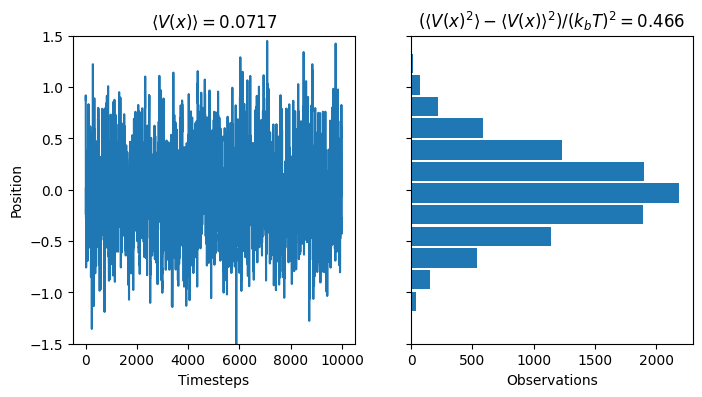

In [6]:
def andrea_anderson_thermostat(md):
    sigma = np.sqrt(md.kT) #/m is omitted, m=1
    v = np.random.normal(0, sigma)
    md.set_velocity(v)


md = MolDynSystem(spring, x=1)
xs = []
for _ in range(10000):
    # do 50 constant energy steps
    x = velocity_verlet(md, N=50)
    # add the final position to your sample
    xs.append(x[-1])
    # apply the thermostat
    andrea_anderson_thermostat(md)

fig, axes = plt.subplots(1,2,figsize=(8,4), sharey=True)

axes[0].plot(np.arange(timesteps), xs)
axes[0].set_ylabel('Position')
axes[0].set_xlabel('Timesteps')
axes[0].set_title(r'$\langle V(x)\rangle=$'+f'{md.thermal_avg(xs):.3g}')

N_bins = 15
bin_shift = abs(max(xs)-min(xs))/N_bins/2 # to center bins
counts, bin_edges = np.histogram(xs, bins=N_bins, range=(min(xs)-bin_shift, max(xs)+bin_shift))
bin_width = bin_edges[1] - bin_edges[0]
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
axes[1].barh(bin_centers, counts, height=bin_width*0.9)
axes[1].set_xlabel('Observations')
axes[1].set_title(r'$(\langle V(x)^2\rangle-\langle V(x)\rangle^2)/(k_bT)^2=$'+f'{md.thermal_fluctuations(xs):.3g}')

for ax in axes:
    ax.set_ylim(-1.5,1.5)

# W04B - Double Well Potential

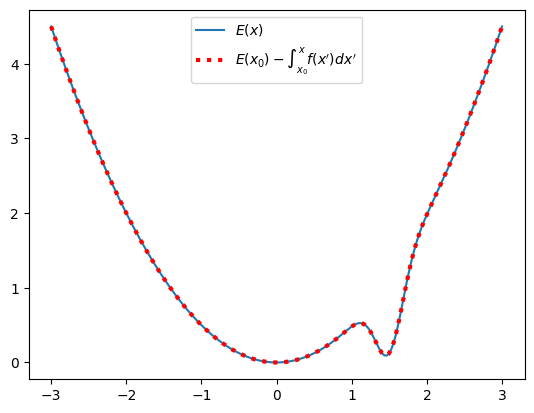

In [7]:
# def potential(x, x0=0, k=1, A=-1, x1=1.5, lamb=0.25):
#     return 

fig, ax = plt.subplots()
# xs = np.linspace(-3.2, 3.2, 200)
# ax.plot(xs, potential(xs))

class  DoubleWell ():
    def __init__(self ,k=1, x0= 0, A=-1, x1=1.5 , l=0.25, xmin=-3, xmax=3):
        self.k = k
        self.x0 = x0
        self.A = A
        self.x1 = x1
        self.l = l

        self.xmin = xmin
        self.xmax = xmax
        self.xspace = np.linspace(self.xmin, self.xmax, 200)
        self.energies = self.potential_energy(self.xspace)
        self.forces = self.force(self.xspace)
        self.integrated_forces = self.integrated_force(self.xspace)

    def potential_energy (self , x):
        return 1/2 * self.k * (x-self.x0)**2 + self.A * np.exp(-(x-self.x1)**2/self.l/self.l)
    
    def force(self, x):
        # F = -dU/dx
        return -self.k*(x-self.x0)+(2*self.A*(x-self.x1)*np.exp(-(x-self.x1)**2/self.l/self.l))/self.l/self.l

    def integrated_force(self, x):
        integrated = []
        for i in range(0, len(x)):
            integration_space = np.linspace(self.x0, x[i])
            force_space = self.force(integration_space)
            integral = np.trapezoid(force_space, integration_space)
            integrated.append(self.potential_energy(self.x0) - integral)
        return integrated

    def plot(self, ax):
        ax.plot(self.xspace, self.energies, label=r'$E(x)$')
        ax.plot(self.xspace, self.integrated_forces, 'r:', linewidth=3, label=r"$E(x_0)-\int_{x_0}^{x}f(x')dx'$")
        ax.legend()
    
double_well = DoubleWell()
double_well.plot(ax)


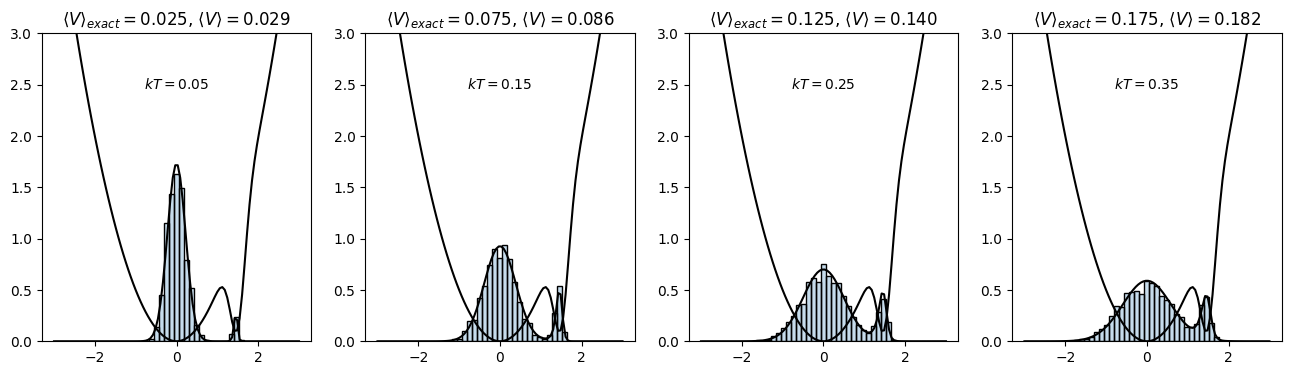

In [11]:

fig, axes = plt.subplots(1,4,figsize=(16,4))

for kT, ax in zip([0.05, 0.15, 0.25, 0.35],axes):
    metro_mc = MetropolisMonteCarlo(double_well, kT=kT, Nsamples=10_000)
    metro_mc.plot(ax)

-6.941357474570962e-20 1.1133778982098064e-14
-6.941357474570962e-20 1.1133778982098064e-14
-6.941357474570962e-20 1.1133778982098064e-14
-6.941357474570962e-20 1.1133778982098064e-14


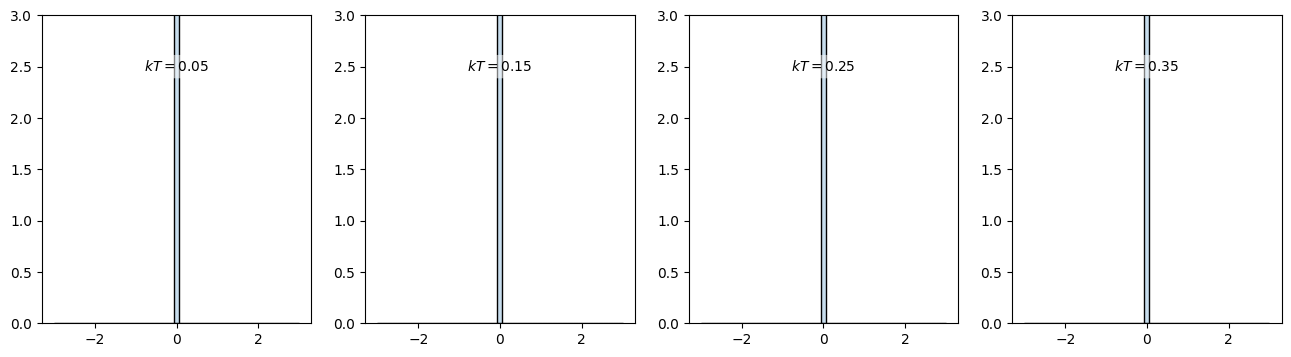

In [21]:
fig, axes = plt.subplots(1,4,figsize=(16,4))

for ax, kT in zip(axes, [0.05,0.15,0.25,0.35]):
    # start the oscillator out somewhere out of equilibrium (it defaults to zero velocity)
    md = MolDynSystem(double_well, x=double_well.x0, kT=kT)
    # Now get the positions from the molecular dynamics simulation
    timesteps = 10000
    xs = velocity_verlet(md, N=timesteps)

    xmin = double_well.xmin
    xmax = double_well.xmax
    print(min(xs), max(xs))
    counts, bin_edges = np.histogram(xs, bins=abs(xmax-xmin)*8+1, range=(xmin, xmax))
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]
    P = counts/bin_width

    ax.bar(bin_centers, P, width=bin_width, facecolor ='C0', alpha =0.25)
    ax.bar(bin_centers, P, width=bin_width, facecolor ='None', edgecolor ='k')
    # ax.set_title(r'$\langle V\rangle_{exact}=$'+f'{thermal_avg_exact():.3f}'+', 'r'$\langle V\rangle=$'+f'{thermal_avg():.3f}')
    # ax.plot(xspace, p_exact, 'k')
    # ax.plot(xspace, calc.potential_energy(xspace), 'k')
    ax.text(0, 2.5, r'$kT=$'+f'{kT}', ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.5,edgecolor='none'))
    ax.set_ylim(0,3)